In [14]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

In [15]:
import sys
sys.path.append("/home/pavan-x1/Projects/Med-Seg-AI")

In [16]:
from app.ML_models.Brain_Tumor_Segmentation.utils import get_model

model = get_model()

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [8]:
def predict_tumor(img : np.array):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    img = img/255
    img_resized = img[np.newaxis, :, :, : ]
    predicted_img = model.predict(img_resized)
    return predicted_img,img

1/1 [==============================] - 0s 260ms/step


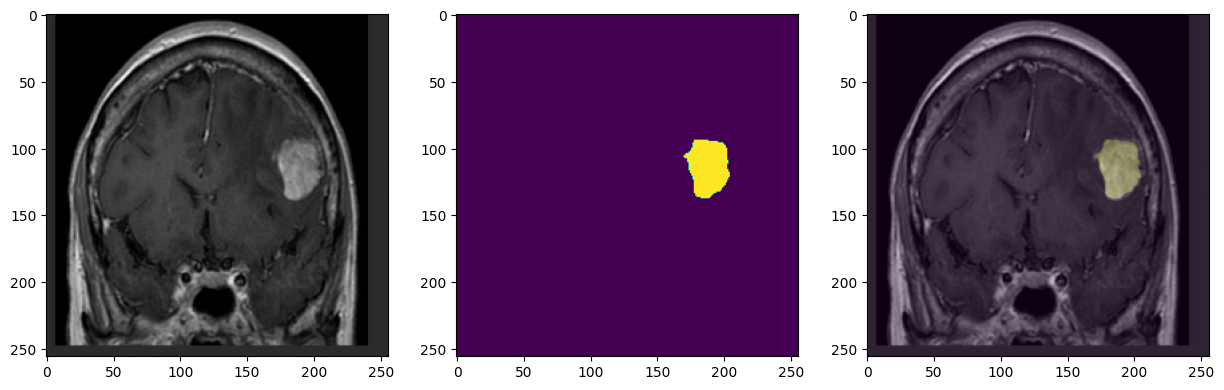

In [9]:
image_path = Path("/home/pavan-x1/Projects/Med-Seg-AI/app/ML_models/Brain_Tumor_Segmentation/archive/Screenshot_2-4-2026_17174_www.bing.com.jpeg")

image = cv2.imread(str(image_path))
predicted_img, img = predict_tumor(image)

fig,ax = plt.subplots(1,3,figsize=(15,5))
ax[0].imshow(img)
ax[1].imshow(np.squeeze(predicted_img) > 0.5 )
ax[2].imshow(img)
ax[2].imshow(np.squeeze(predicted_img) > 0.5, alpha=0.2)
plt.show()